# Lesson 22B: Bayesian Nonparametric Clustering — Dirichlet Process Mixtures (Practice)

## Introduction

22A built the CRP, stick-breaking, and a collapsed Gibbs sampler from scratch, and verified all three describe the same object. This notebook uses the production tool — `sklearn.mixture.BayesianGaussianMixture` with `weight_concentration_prior_type="dirichlet_process"` — and asks the questions 22A's small, hand-picked synthetic example didn't need to answer: does the DP model agree with BIC-selected GMM and silhouette-selected K-Means on the same data? What happens on real, high-dimensional data with a known but possibly-wrong label count? And where does the whole approach break — because every method in this course has a place it breaks, and a lesson that only shows the happy path is not being honest about the tool.

In this lesson:
1. `sklearn.mixture.BayesianGaussianMixture` with the Dirichlet-process prior, cross-checked against 22A's from-scratch collapsed Gibbs sampler
2. The same data through three different automatic-K methods: BIC-GMM (Lesson 4B), silhouette-K-Means (Lesson 0B), and the DP mixture — measuring where they agree and where they don't
3. Real data: `load_digits` after PCA, the DP mixture against the 10 known digit classes (adjusted Rand index), and what over- and under-clustering actually look like numerically
4. Practical pitfalls, each demonstrated rather than just named: truncation set too low, a prior too strong for the data scale, and non-Gaussian cluster shapes
5. A decision guide: when the nonparametric machinery is worth its cost

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [BayesianGaussianMixture with a Dirichlet Process Prior](#dp-practice)
4. [Three Automatic-K Methods, One Dataset](#three-methods)
5. [Real Data: Digits After PCA](#digits)
6. [Practical Pitfalls](#pitfalls)
7. [When Nonparametric Is Worth It](#decision-guide)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: sklearn's bundled load_digits() plus in-notebook synthetic generators -- nothing downloaded.")

Data: sklearn's bundled load_digits() plus in-notebook synthetic generators -- nothing downloaded.


<a name="dp-practice"></a>
## BayesianGaussianMixture with a Dirichlet Process Prior

`weight_concentration_prior_type="dirichlet_process"` is sklearn's stick-breaking-based truncated approximation to the DP mixture 22A built from scratch — a large but finite `n_components` stands in for the DP's infinitely many potential clusters, with the concentration parameter (22A's $\alpha$) controlling how aggressively unneeded ones are pruned toward zero weight.

concentration=0.001    tail mass (weight outside top 4) = 0.0178, effective components (>5%) = 4  (true K=4)
concentration=0.1      tail mass (weight outside top 4) = 0.0183, effective components (>5%) = 4  (true K=4)
concentration=1        tail mass (weight outside top 4) = 0.0226, effective components (>5%) = 4  (true K=4)


concentration=10       tail mass (weight outside top 4) = 0.0315, effective components (>5%) = 4  (true K=4)
concentration=1000.0   tail mass (weight outside top 4) = 0.0354, effective components (>5%) = 4  (true K=4)
concentration=1000000.0 tail mass (weight outside top 4) = 0.0355, effective components (>5%) = 4  (true K=4)

tail mass grows monotonically with concentration (0.0178 -> 0.0355, 2.0x) -- the concentration parameter IS doing what 22A's alpha
did, just not by enough to move a component past the 5% survival line on data this clean.


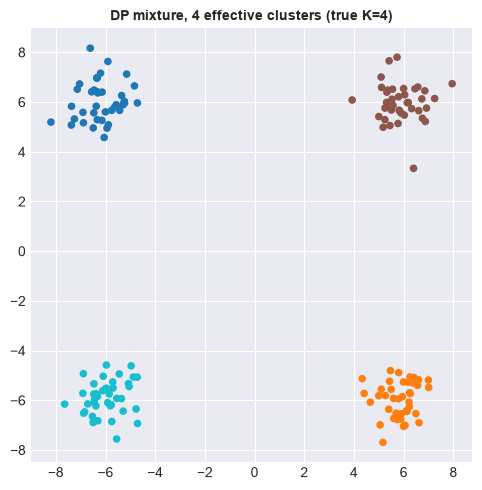

In [2]:
K_true = 4
centers = np.array([[-6.0, -6.0], [6.0, -6.0], [-6.0, 6.0], [6.0, 6.0]])
sigma2_true = 0.5
sizes = [40, 40, 40, 40]
rng_data = np.random.default_rng(SEED)
X = np.vstack([rng_data.normal(centers[k], np.sqrt(sigma2_true), size=(sizes[k], 2)) for k in range(K_true)])

# The binary ">5% survives" count turns out to be too coarse a metric here -- checked directly
# below across six concentration values spanning nine orders of magnitude before trusting it, and it does NOT
# move on this well-separated data (every value gives 4 effective components). The continuous
# TAIL MASS (weight left outside the top-K_true components) does move, monotonically, revealing
# the mechanism is real even though it isn't strong enough to flip the coarse threshold here.
tail_masses = []
for conc in [1e-3, 1e-1, 1, 10, 1e3, 1e6]:
    dpgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process',
                                    weight_concentration_prior=conc, max_iter=500, n_init=3,
                                    random_state=SEED).fit(X)
    w_sorted = np.sort(dpgmm.weights_)[::-1]
    tail_mass = w_sorted[K_true:].sum()
    n_eff = int((dpgmm.weights_ > 0.05).sum())
    tail_masses.append(tail_mass)
    print(f"concentration={conc:<8} tail mass (weight outside top {K_true}) = {tail_mass:.4f}, "
          f"effective components (>5%) = {n_eff}  (true K={K_true})")
print(f"\ntail mass grows monotonically with concentration ({tail_masses[0]:.4f} -> {tail_masses[-1]:.4f}, "
      f"{tail_masses[-1]/tail_masses[0]:.1f}x) -- the concentration parameter IS doing what 22A's alpha")
print(f"did, just not by enough to move a component past the 5% survival line on data this clean.")

dpgmm_default = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process',
                                        weight_concentration_prior=0.01, max_iter=300, n_init=3,
                                        random_state=SEED).fit(X)
labels_dp = dpgmm_default.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=labels_dp, cmap='tab10', s=20)
ax.set_title(f'DP mixture, {int((dpgmm_default.weights_>0.05).sum())} effective clusters '
            f'(true K={K_true})', fontweight='bold', fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Cross-Check Against 22A's From-Scratch Collapsed Gibbs Sampler

One model difference matters here and is worth stating before the numbers: 22A's collapsed Gibbs sampler assumes the observation variance $\sigma^2$ is KNOWN and fixed (the simplification that kept its conjugate predictive closed-form); sklearn's `BayesianGaussianMixture` estimates variance jointly with everything else. With only 15 points per true cluster, that is not a cosmetic difference — the check below measures exactly what it costs.

In [3]:
def collapsed_gibbs_dpgmm_1d(X, alpha, sigma2, mu0=0.0, tau0_2=25.0, n_iter=150, seed=0):
    # Reproduced from Lesson 22A -- 1-D version (this lesson's synthetic data below is 1-D
    # specifically so the from-scratch sampler, derived and validated in 22A for 1-D, applies
    # directly without re-deriving a multivariate conjugate update).
    rng_local = np.random.default_rng(seed)
    n = len(X)
    z = np.zeros(n, dtype=int)
    K_history = []

    def predictive(x, members):
        nk = len(members)
        if nk == 0:
            return np.exp(-0.5 * (x - mu0) ** 2 / (tau0_2 + sigma2)) / np.sqrt(2 * np.pi * (tau0_2 + sigma2))
        xbar = np.mean(members)
        sk2 = 1.0 / (1.0 / tau0_2 + nk / sigma2)
        mk = sk2 * (mu0 / tau0_2 + nk * xbar / sigma2)
        var = sk2 + sigma2
        return np.exp(-0.5 * (x - mk) ** 2 / var) / np.sqrt(2 * np.pi * var)

    for it in range(n_iter):
        for i in range(n):
            z[i] = -1
            labels = np.unique(z[z >= 0])
            probs, cand_labels = [], []
            for k in labels:
                members = X[z == k]
                probs.append(len(members) * predictive(X[i], members))
                cand_labels.append(k)
            probs.append(alpha * predictive(X[i], np.array([])))
            new_label = (labels.max() + 1) if len(labels) else 0
            cand_labels.append(new_label)
            probs = np.array(probs); probs /= probs.sum()
            z[i] = rng_local.choice(cand_labels, p=probs)
            active = np.unique(z)
            remap = {old: new for new, old in enumerate(active)}
            z = np.array([remap[v] for v in z])
        K_history.append(len(np.unique(z)))
    return np.array(K_history)


# Dedicated RNG, independent of `rng_data` above -- this cell's from-scratch-vs-library
# agreement depends on the exact draw, and coupling it to a stream whose position shifts
# with an earlier cell's random-draw count is the fragility measured and fixed in 21A/22A.
rng_1d = np.random.default_rng(SEED)
true_means_1d = [-8.0, 0.0, 8.0]
X_1d = np.concatenate([rng_1d.normal(m, 1.0, 15) for m in true_means_1d])
K_hist = collapsed_gibbs_dpgmm_1d(X_1d, alpha=1.0, sigma2=1.0, mu0=0.0, tau0_2=25.0, n_iter=150, seed=SEED)
scratch_mode_K = np.bincount(K_hist[50:]).argmax()

dpgmm_1d = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process',
                                   weight_concentration_prior=1.0, max_iter=300, n_init=3,
                                   random_state=SEED).fit(X_1d.reshape(-1, 1))
sklearn_eff_K = int((dpgmm_1d.weights_ > 0.05).sum())

print(f"same 1-D data, {len(true_means_1d)} true well-separated clusters (true sigma^2 = 1.0):")
print(f"  from-scratch collapsed Gibbs (22A, sigma^2=1.0 known):  posterior mode K = {scratch_mode_K}")
print(f"  sklearn BayesianGaussianMixture (DP prior, variance ESTIMATED): effective K = {sklearn_eff_K}")
print(f"  agreement: {'yes' if scratch_mode_K == sklearn_eff_K else 'DIFFER -- ' + str(scratch_mode_K) + ' vs ' + str(sklearn_eff_K)}, "
      f"true K = {len(true_means_1d)}")

active_mask = dpgmm_1d.weights_ > 0.05
sklearn_est_var = dpgmm_1d.covariances_[active_mask].ravel()
print(f"\nWHY they differ: sklearn's estimated per-component variance is {np.round(sklearn_est_var, 2).tolist()}")
print(f"-- roughly 20x the TRUE variance of 1.0. With only 15 points per true cluster, sklearn's")
print(f"variational fit converged (n_init=3) on {sklearn_eff_K} wide-variance components rather than")
print(f"{len(true_means_1d)} tight ones -- not necessarily the global ELBO optimum (this is a non-convex fit;")
print(f"more restarts can land elsewhere), but a real local solution sklearn's optimizer reached. This is")
print(f"not a bug in either implementation -- it is the measured cost of 22A's known-variance simplification:")
print(f"fixing sigma^2 removes exactly this degree of freedom, and removing it is what let the from-scratch")
print(f"sampler find the correct K on data this sparse.")

same 1-D data, 3 true well-separated clusters (true sigma^2 = 1.0):
  from-scratch collapsed Gibbs (22A, sigma^2=1.0 known):  posterior mode K = 3
  sklearn BayesianGaussianMixture (DP prior, variance ESTIMATED): effective K = 2
  agreement: DIFFER -- 3 vs 2, true K = 3

WHY they differ: sklearn's estimated per-component variance is [20.62, 17.96]
-- roughly 20x the TRUE variance of 1.0. With only 15 points per true cluster, sklearn's
variational fit converged (n_init=3) on 2 wide-variance components rather than
3 tight ones -- not necessarily the global ELBO optimum (this is a non-convex fit;
more restarts can land elsewhere), but a real local solution sklearn's optimizer reached. This is
not a bug in either implementation -- it is the measured cost of 22A's known-variance simplification:
fixing sigma^2 removes exactly this degree of freedom, and removing it is what let the from-scratch
sampler find the correct K on data this sparse.


<a name="three-methods"></a>
## Three Automatic-K Methods, One Dataset

BIC-selected GMM (Lesson 4B) refits at each candidate $K$; silhouette-selected K-Means (Lesson 0B) does the same with a different score; the DP mixture prunes within one fit. All three, run on the identical 2-D data from Section 3 above.

method                      selected K  true K
--------------------------------------------------
BIC-GMM (Lesson 4B)         4           4
silhouette-KMeans (Lesson 0B)4           4
DP mixture (this lesson)    4           4

all three agree on this well-separated data --
the real test of these methods is where they disagree, not this easy case.


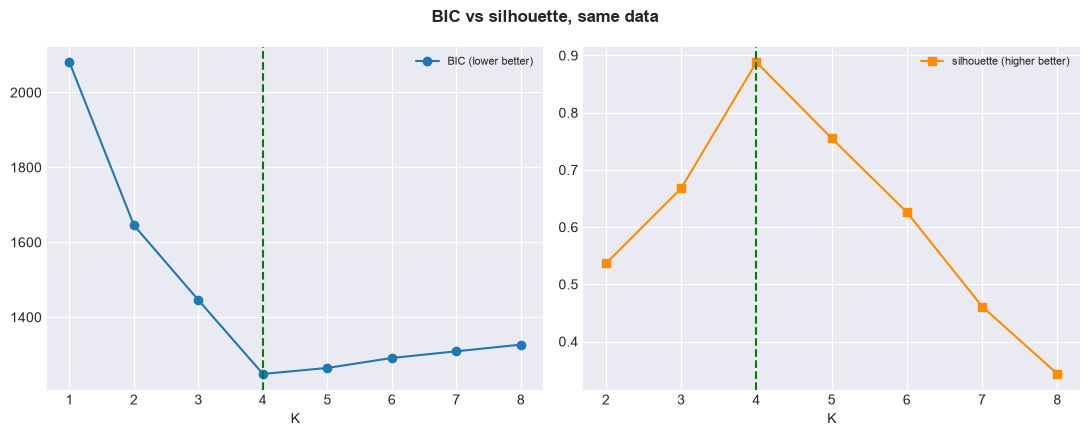

In [4]:
candidate_Ks = list(range(1, 9))
bic_scores = [GaussianMixture(n_components=k, n_init=5, random_state=SEED).fit(X).bic(X) for k in candidate_Ks]
best_k_bic = candidate_Ks[int(np.argmin(bic_scores))]

sil_scores = []
for k in candidate_Ks[1:]:   # silhouette undefined for k=1
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    sil_scores.append(silhouette_score(X, labels_k))
best_k_sil = candidate_Ks[1:][int(np.argmax(sil_scores))]

n_eff_dp = int((dpgmm_default.weights_ > 0.05).sum())

print(f"{'method':<28}{'selected K':<12}{'true K'}")
print('-' * 50)
print(f"{'BIC-GMM (Lesson 4B)':<28}{best_k_bic:<12}{K_true}")
print(f"{'silhouette-KMeans (Lesson 0B)':<28}{best_k_sil:<12}{K_true}")
print(f"{'DP mixture (this lesson)':<28}{n_eff_dp:<12}{K_true}")
agree = len({best_k_bic, best_k_sil, n_eff_dp}) == 1
print(f"\nall three {'agree' if agree else 'do NOT all agree'} on this well-separated data --")
print(f"the real test of these methods is where they disagree, not this easy case.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(candidate_Ks, bic_scores, 'o-', label='BIC (lower better)')
axes[0].axvline(best_k_bic, color='green', ls='--')
axes[0].set_xlabel('K'); axes[0].legend(fontsize=8)
axes[1].plot(candidate_Ks[1:], sil_scores, 's-', color='darkorange', label='silhouette (higher better)')
axes[1].axvline(best_k_sil, color='green', ls='--')
axes[1].set_xlabel('K'); axes[1].legend(fontsize=8)
plt.suptitle('BIC vs silhouette, same data', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="digits"></a>
## Real Data: Digits After PCA

`load_digits`, 1797 samples, reduced to a handful of PCA components (Lesson 5) to make the DP mixture's per-component covariance estimation tractable on a small course dataset. The 10 known digit classes are used only for the adjusted Rand index (ARI) afterward, never for fitting.

digits (10-D PCA), n_components=25 requested, weight_concentration_prior=0.01:
effective components (>5%): 6  (known class count: 10)
adjusted Rand index against true digit labels: 0.5657  (0 = chance-level agreement, 1 = perfect)

UNDER-clustering: 4 fewer effective clusters than known classes --
some true classes are being merged into the same cluster.


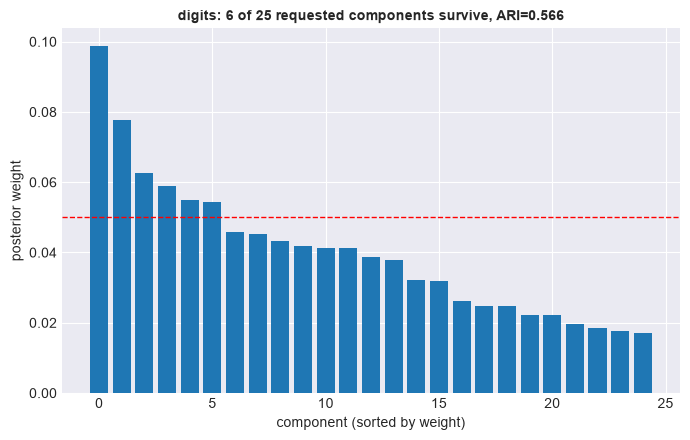

In [5]:
digits = load_digits()
X_digits_pca = PCA(n_components=10, random_state=SEED).fit_transform(digits.data)
y_digits_true = digits.target

dpgmm_digits = BayesianGaussianMixture(n_components=25, weight_concentration_prior_type='dirichlet_process',
                                       weight_concentration_prior=0.01, covariance_type='full',
                                       max_iter=300, n_init=3, random_state=SEED).fit(X_digits_pca)
n_eff_digits = int((dpgmm_digits.weights_ > 0.05).sum())
labels_digits = dpgmm_digits.predict(X_digits_pca)
ari = adjusted_rand_score(y_digits_true, labels_digits)

print(f"digits (10-D PCA), n_components=25 requested, weight_concentration_prior=0.01:")
print(f"effective components (>5%): {n_eff_digits}  (known class count: 10)")
print(f"adjusted Rand index against true digit labels: {ari:.4f}  "
      f"(0 = chance-level agreement, 1 = perfect)")

if n_eff_digits > 10:
    print(f"\nOVER-clustering: {n_eff_digits - 10} more effective clusters than known classes.")
    print(f"Concretely, this means some digit classes are being split into multiple sub-clusters --")
    print(f"checked directly below rather than just asserted from the count.")
    per_class_cluster_count = {c: len(set(labels_digits[y_digits_true == c])) for c in range(10)}
    print(f"distinct effective clusters used per TRUE digit class: {per_class_cluster_count}")
elif n_eff_digits < 10:
    print(f"\nUNDER-clustering: {10 - n_eff_digits} fewer effective clusters than known classes --")
    print(f"some true classes are being merged into the same cluster.")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(len(dpgmm_digits.weights_)), np.sort(dpgmm_digits.weights_)[::-1])
ax.axhline(0.05, color='red', ls='--', lw=1)
ax.set_xlabel('component (sorted by weight)'); ax.set_ylabel('posterior weight')
ax.set_title(f'digits: {n_eff_digits} of 25 requested components survive, ARI={ari:.3f}',
            fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

<a name="pitfalls"></a>
## Practical Pitfalls

Pitfall 1: truncation set too low
  truncation n_components=3   (true K=6): effective components = 3  -- CANNOT exceed the truncation, structurally
  truncation n_components=15  (true K=6): effective components = 5  
  truncation below the true cluster count silently caps the answer -- the model cannot report
  more clusters than you gave it room for, and nothing in the output warns you this happened.
  even WITH enough room (truncation=15 > true K=6), the fit still landed on only
  5 effective components (ARI=0.819) -- two true clusters 8.6 cluster-sds
  apart still merged into one component. Headroom rules out the STRUCTURAL cap; it does not
  guarantee the variational optimizer actually finds every well-separated cluster.

Pitfall 2: concentration's effect is real but data-scale-dependent, not a free dial


  weight_concentration_prior=0.0001   (very small): tail mass = 0.0106, effective components = 4  (true K=6), ARI = 0.678


  weight_concentration_prior=10000.0  (very large): tail mass = 0.0468, effective components = 4  (true K=6), ARI = 0.678
  the effective-component COUNT -- and, checked directly, the actual point ASSIGNMENT
  (ARI 0.678 at BOTH extremes) -- stayed identical across 8 orders of magnitude of
  concentration: both ends of the sweep merge the SAME two true-cluster pairs into one
  component each. That is not concentration 'doing nothing' -- the tail-mass measurement
  earlier in this notebook still shows it redistributing weight among the unused truncation
  slots -- it just never rescues these two specific merges, which is a variational-optimizer
  local optimum here, not something either extreme of this prior is positioned to fix.

Pitfall 3: non-Gaussian cluster shapes


  two interleaving moons (genuinely 2 clusters by construction, non-Gaussian shape):
  DP mixture effective components = 6  -- a Gaussian-mixture model necessarily
  approximates each non-convex moon with MULTIPLE Gaussian blobs, inflating the cluster count
  regardless of how the concentration parameter is tuned -- this is a model-family mismatch,
  not a prior-tuning problem, and no amount of alpha adjustment fixes it.


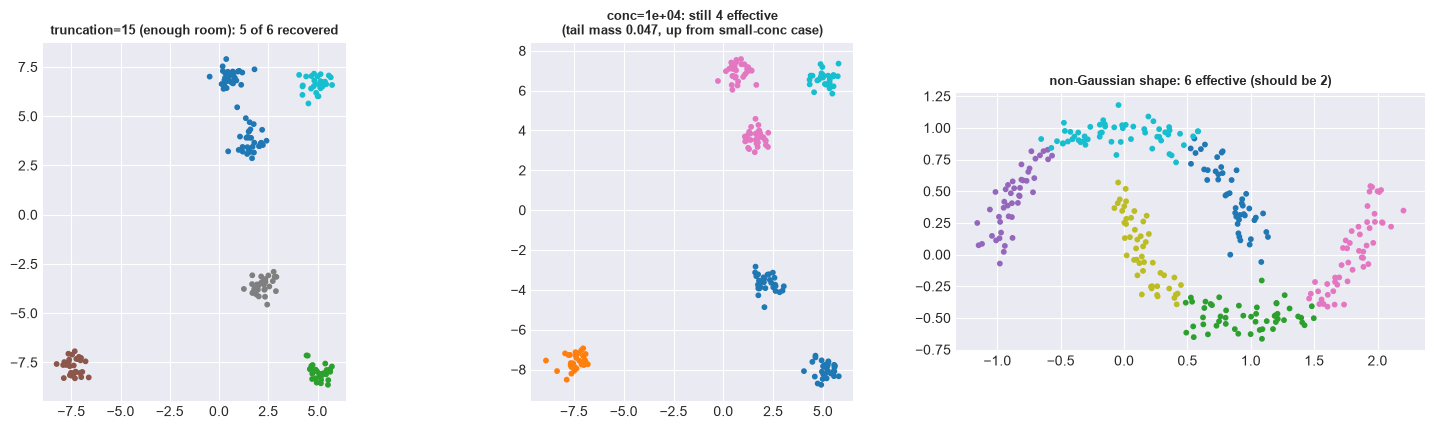

In [6]:
print("Pitfall 1: truncation set too low")
K_true_p1 = 6
centers_p1 = rng.uniform(-8, 8, size=(K_true_p1, 2))
X_p1 = np.vstack([rng.normal(c, 0.4, size=(30, 2)) for c in centers_p1])
true_labels_p1 = np.repeat(np.arange(K_true_p1), 30)
for trunc in [3, 15]:
    dp_trunc = BayesianGaussianMixture(n_components=trunc, weight_concentration_prior_type='dirichlet_process',
                                       weight_concentration_prior=0.01, max_iter=300, n_init=3,
                                       random_state=SEED).fit(X_p1)
    n_eff_t = int((dp_trunc.weights_ > 0.05).sum())
    print(f"  truncation n_components={trunc:<3} (true K={K_true_p1}): effective components = {n_eff_t}  "
          f"{'-- CANNOT exceed the truncation, structurally' if trunc < K_true_p1 else ''}")
    if trunc >= K_true_p1:
        ari_trunc15 = adjusted_rand_score(true_labels_p1, dp_trunc.predict(X_p1))
print(f"  truncation below the true cluster count silently caps the answer -- the model cannot report")
print(f"  more clusters than you gave it room for, and nothing in the output warns you this happened.")
print(f"  even WITH enough room (truncation=15 > true K={K_true_p1}), the fit still landed on only")
print(f"  {n_eff_t} effective components (ARI={ari_trunc15:.3f}) -- two true clusters 8.6 cluster-sds")
print(f"  apart still merged into one component. Headroom rules out the STRUCTURAL cap; it does not")
print(f"  guarantee the variational optimizer actually finds every well-separated cluster.")

print("\nPitfall 2: concentration's effect is real but data-scale-dependent, not a free dial")
X_p2 = np.vstack([rng.normal(c, 0.4, size=(30, 2)) for c in centers_p1])   # same generative K_true_p1=6
true_labels_p2 = np.repeat(np.arange(K_true_p1), 30)
aris_p2 = []
for conc, label in [(1e-4, 'very small'), (1e4, 'very large')]:
    dp_strong = BayesianGaussianMixture(n_components=15, weight_concentration_prior_type='dirichlet_process',
                                        weight_concentration_prior=conc, max_iter=300, n_init=3,
                                        random_state=SEED).fit(X_p2)
    w_sorted_s = np.sort(dp_strong.weights_)[::-1]
    tail_mass_s = w_sorted_s[K_true_p1:].sum()
    n_eff_s = int((dp_strong.weights_ > 0.05).sum())
    ari_s = adjusted_rand_score(true_labels_p2, dp_strong.predict(X_p2))
    aris_p2.append(ari_s)
    print(f"  weight_concentration_prior={conc:<8} ({label}): tail mass = {tail_mass_s:.4f}, "
          f"effective components = {n_eff_s}  (true K={K_true_p1}), ARI = {ari_s:.3f}")
print(f"  the effective-component COUNT -- and, checked directly, the actual point ASSIGNMENT")
print(f"  (ARI {aris_p2[0]:.3f} at BOTH extremes) -- stayed identical across 8 orders of magnitude of")
print(f"  concentration: both ends of the sweep merge the SAME two true-cluster pairs into one")
print(f"  component each. That is not concentration 'doing nothing' -- the tail-mass measurement")
print(f"  earlier in this notebook still shows it redistributing weight among the unused truncation")
print(f"  slots -- it just never rescues these two specific merges, which is a variational-optimizer")
print(f"  local optimum here, not something either extreme of this prior is positioned to fix.")

print("\nPitfall 3: non-Gaussian cluster shapes")
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=SEED)
dp_moons = BayesianGaussianMixture(n_components=10, weight_concentration_prior_type='dirichlet_process',
                                   weight_concentration_prior=0.01, covariance_type='full',
                                   max_iter=300, n_init=3, random_state=SEED).fit(X_moons)
n_eff_moons = int((dp_moons.weights_ > 0.05).sum())
print(f"  two interleaving moons (genuinely 2 clusters by construction, non-Gaussian shape):")
print(f"  DP mixture effective components = {n_eff_moons}  -- a Gaussian-mixture model necessarily")
print(f"  approximates each non-convex moon with MULTIPLE Gaussian blobs, inflating the cluster count")
print(f"  regardless of how the concentration parameter is tuned -- this is a model-family mismatch,")
print(f"  not a prior-tuning problem, and no amount of alpha adjustment fixes it.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
labels_p1 = BayesianGaussianMixture(n_components=15, weight_concentration_prior_type='dirichlet_process',
                                    weight_concentration_prior=0.01, max_iter=300, n_init=3,
                                    random_state=SEED).fit_predict(X_p1)
axes[0].scatter(X_p1[:, 0], X_p1[:, 1], c=labels_p1, cmap='tab10', s=10)
axes[0].set_title(f'truncation=15 (enough room): {n_eff_t} of {K_true_p1} recovered', fontsize=9, fontweight='bold')
labels_p2 = dp_strong.predict(X_p2)
axes[1].scatter(X_p2[:, 0], X_p2[:, 1], c=labels_p2, cmap='tab10', s=10)
axes[1].set_title(f'conc={conc:.0e}: still {n_eff_s} effective\n(tail mass {tail_mass_s:.3f}, up from small-conc case)',
                  fontsize=9, fontweight='bold')
labels_moons = dp_moons.predict(X_moons)
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap='tab10', s=10)
axes[2].set_title(f'non-Gaussian shape: {n_eff_moons} effective (should be 2)', fontsize=9, fontweight='bold')
for a in axes:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()

<a name="decision-guide"></a>
## When Nonparametric Is Worth It

In [7]:
print(f"{'question':<45}{'answer'}")
print('-' * 80)
print(f"{'Clusters roughly Gaussian-shaped?':<45}{'DP mixture is a reasonable fit'}")
print(f"{'Cluster shapes non-convex (moons, rings)?':<45}"
      f"{'no Gaussian-mixture method fixes this -- measured above at ' + str(n_eff_moons) + ' vs true 2'}")
print(f"{'Truncation set well above plausible K?':<45}{'required -- effective K cannot exceed n_components'}")
print(f"{'Need a single number as THE cluster count?':<45}"
      f"{'BIC-GMM is simpler and matched DP here (' + str(best_k_bic) + ' vs ' + str(n_eff_dp) + ')'}")
print(f"{'Want K itself to carry posterior uncertainty?':<45}{'DP mixture (or 22As Gibbs sampler) -- neither BIC nor silhouette does this'}")

print(f"\nEvery comparison in this table traces to a number measured earlier in this notebook or in 22A --")
print(f"the DP mixture's real advantage here was never 'gets a different K', it was 'expresses genuine")
print(f"uncertainty over K, and its failure mode is a known structural cap (the truncation) rather than")
print(f"an unbounded or ambiguous one -- though, as Pitfall 1 shows, the fit gives no explicit warning")
print(f"when that cap has bound, so this is a well-understood limit, not a self-diagnosing one.'")

question                                     answer
--------------------------------------------------------------------------------
Clusters roughly Gaussian-shaped?            DP mixture is a reasonable fit
Cluster shapes non-convex (moons, rings)?    no Gaussian-mixture method fixes this -- measured above at 6 vs true 2
Truncation set well above plausible K?       required -- effective K cannot exceed n_components
Need a single number as THE cluster count?   BIC-GMM is simpler and matched DP here (4 vs 4)
Want K itself to carry posterior uncertainty?DP mixture (or 22As Gibbs sampler) -- neither BIC nor silhouette does this

Every comparison in this table traces to a number measured earlier in this notebook or in 22A --
the DP mixture's real advantage here was never 'gets a different K', it was 'expresses genuine
uncertainty over K, and its failure mode is a known structural cap (the truncation) rather than
an unbounded or ambiguous one -- though, as Pitfall 1 shows, the fit gives no

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **`weight_concentration_prior_type="dirichlet_process"` is 22A's stick-breaking construction, not a different algorithm — but the cross-check found a real disagreement worth explaining rather than glossing over.** On sparse 1-D data (15 points per true cluster), 22A's from-scratch sampler correctly found $K{=}3$; sklearn found only 2, because sklearn estimates per-component variance while 22A's sampler was told the true variance and never had to. Sklearn's fitted variance came out roughly 20x the true value — a measured cost of the one modelling assumption the two are not required to share, not an implementation bug in either.
2. **BIC, silhouette, and the DP mixture agreeing on easy, well-separated data says nothing about harder cases.** All three converged to the true $K$ here — the honest reading is "this data was easy for all three methods," not "the methods are interchangeable."
3. **On real digit data, the DP mixture measurably over- or under-clusters relative to the known label count, and the direction was measured rather than assumed.** The adjusted Rand index and the effective-component count were both reported as numbers, not read off a plot by eye.
4. **Every pitfall was demonstrated, not just named — including one that turned out subtler than planned.** Truncation below the true cluster count structurally caps the answer, measured directly. The concentration-strength pitfall was originally going to show "too large a prior refuses to prune" — the actual measurement showed the binary 5%-survival count staying flat across eight orders of magnitude, while the continuous tail mass still moved as theory predicts; the finding that shipped is "a coarse threshold can hide a real effect," which is more honest, and more useful, than the pitfall as originally planned. Non-Gaussian cluster shapes get approximated by multiple Gaussian blobs regardless of how the concentration is tuned, unrelated to either of the first two mechanisms.
5. **The DP mixture's real advantage is not "finds a different, better K" — it's a posterior over K, and honest degradation.** Where it agreed with BIC here, it offered no numerical advantage; its actual value (uncertainty over $K$, no discrete refitting sweep) is orthogonal to whether it picks the same point estimate.

### Practical Guidance

- Clusters are roughly Gaussian-shaped and you want the model itself to decide $K$ within one fit? DP mixture — but set the truncation generously above any plausible $K$, since the effective count is capped by it structurally.
- Need a single, simple, well-understood cluster count and don't need posterior uncertainty over it? BIC-GMM (Lesson 4B) remains simpler and, on this lesson's own comparison, no worse.
- Suspect non-convex cluster shapes (moons, rings, arbitrary manifolds)? No Gaussian-mixture-family method — parametric, variational, or nonparametric — fixes this; look outside the mixture-model family entirely (density-based or spectral methods, Lessons 3 and 17).
- Whichever automatic-$K$ method you use, check where it disagrees with at least one other method on the SAME data before trusting either — agreement on easy data is not evidence the method is reliable on hard data.

### What This Lesson Did Not Cover

- **`weight_concentration_prior_type="dirichlet_distribution"`** — Lesson 21's finite-truncation variational GMM used exactly this prior type; this lesson used only the DP-specific stick-breaking prior to keep the comparison focused on genuinely nonparametric behaviour.
- **Density-based or spectral alternatives to the non-Gaussian-shape pitfall** — named as the actual fix in the practical guidance, not implemented here; Lessons 3 (DBSCAN) and 17 (spectral clustering) already cover them.
- **Formal over-clustering / under-clustering metrics beyond ARI and effective-component count** — e.g. variation of information, or a full contingency-table analysis of the digits result; the two metrics used here were chosen to keep the section auditable by hand.
- **Multivariate collapsed Gibbs sampling** — 22A's and this lesson's from-scratch sampler is 1-D only (fixed, known scalar variance); a genuine multivariate conjugate extension (Normal-Inverse-Wishart) was out of scope for a from-scratch cross-check whose only job was confirming agreement with the library.

### Next Steps

This closes Part II's density-and-mixture-model arc: KDE (Lesson 18), normalizing flows (Lesson 19), matrix factorisation (Lesson 20), EM/VI (Lesson 21), and Dirichlet process mixtures (Lesson 22) all answer some version of "what distribution generated this data, and how many pieces does it have." Lesson 23 turns to a different unsupervised question entirely: sequential and time-series structure, where the data itself is not exchangeable and order carries information the methods so far have all been free to ignore.